96.66666666666667
80.0
150.0
60.0


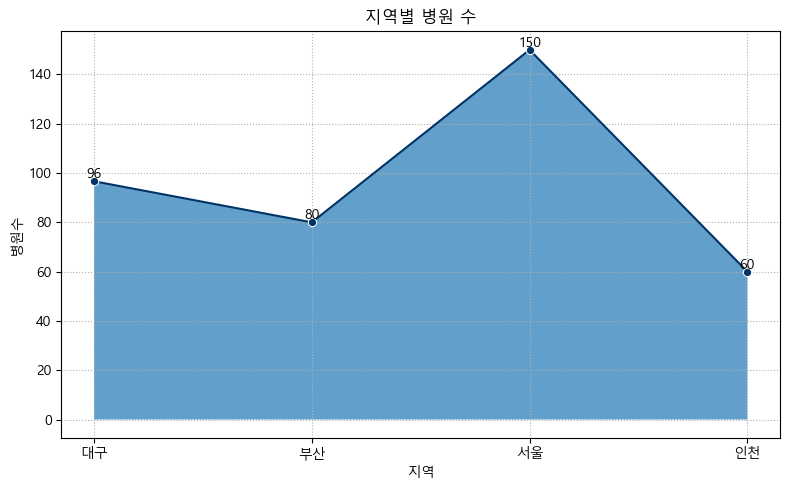

In [4]:

# 반드시 pandas는 import하여 사용
import pandas as pd
import matplotlib.pyplot as plt
# matplotlib기반에서 차트 예쁘게 꾸미는 도구
import seaborn as sns


# 데이터 생성하기
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [100000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# 데이터 병합 (지역 기준)
merged = pd.merge(df1, df2, on="지역", how="outer")

# 결측치 처리
# 총인구 없는 값 -> 평균으로 채우기
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())

# 결과 확인
merged

# 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 설정
plt.figure(figsize=(8, 5))

# 막대그래프 생성
# x축 -> 지역
# y축 -> 병원수
# 세로 막대 넓이 기본값 width = 0.8
# plt.bar(merged["지역"], merged["병원수"], width=0.4)

# 막대 위에 값 표시하기
# 값 표시 안할거면 위에 주석 살리기
# plt.plot(merged["지역"], merged["병원수"], marker='s')
ax = sns.lineplot(
    x='지역',
    y='병원수',
    data=merged,
    marker='o',
    color='#003366'
)

for i in range(len(merged["병원수"])):
    v = merged['병원수'][i]
    print(v)
    ax.text(
        i,
        v,
        int(v),
        ha='center',
        va='bottom'
    )

# 선 아래 영역 채우기
plt.fill_between(merged["지역"], merged["병원수"], alpha=0.7)
plt.grid(linestyle=':')
plt.title("지역별 병원 수")
plt.xlabel("지역")
plt.ylabel("병원수")
plt.tight_layout()
# 그래프 출력
plt.show()